# Methode def

In [27]:
import quimb as qu
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from circuit_generation import *
from tree_class import *
from best_mps_ordering import local_greedy_swap, greedy_weighted_linear_arrangement, plot_graph_comparisons
import pandas as pd


def test_tree_mps(circ,n_qb = 10,max_bond=None,return_memory=False, plot = False):
    G, mst, adj = plot_connectivity_and_max_mst(circ, return_adjacency_matrix=True)

    # permuted MPS

        # derive 'best' permutation from the graph
    perm = greedy_weighted_linear_arrangement(G)
    initial_order = greedy_weighted_linear_arrangement(G)
    perm, final_cost = local_greedy_swap(G, initial_order)

    perm = {i: q for i, q in enumerate(perm)}
        # reverse the permutation for a good mapping of the gates
    # inverse_perm = {'k'+str(i): 'k'+str(perm[i]) for i in perm.keys()}
    inverse_perm = {perm[q]:q for q in perm.keys()}


    # print('--------')
    # print(n_qb)
    # print(perm)
    # print(inverse_perm)

    mps_ordered = qtn.CircuitMPS(n_qb,max_bond=max_bond)
    for gate in circ.gates:
        qubits = gate.qubits  # par exemple (2,) ou (0, 1)
        remapped_qubits = tuple(inverse_perm[q] for q in gate.qubits)

        # mps.apply_gate(gate)
        new_gate = gate.copy()
        new_gate.qubits = np.int64(remapped_qubits)
        mps_ordered.apply_gate(new_gate)

    # reverse effect of permutation
    reindex_dic_ordered = {'k'+str(i): 'k'+str(perm[i]) for i in perm.keys()}
    mps_unperm = mps_ordered.psi.reindex(reindex_dic_ordered)

    if plot : 
        plot_graph_comparisons(G, initial_order, perm)

    # non reordered mps-------------------------------
    mps = qtn.CircuitMPS(n_qb,max_bond=max_bond)
    for gate in circ.gates:
        mps.apply_gate(gate)
    mps_net = mps.psi.contract()
    
    # Tree -------------------------------------------


    tree,trad_dic = tree_from_matrix(adj,0,max_bond=max_bond)
    tree = replicate_circ(circ,tree,trad_dic)

    reindex_dic = {'k'+str(k): 'out'+ str(v) for k, v in trad_dic.items()}
    circ_net_reindexed = circ.psi.reindex_(reindex_dic).contract().H
    tree_net = tree.network

    # Compute fidelity to original circuit
    circ_net = circ.psi.H

    fnet = circ_net_reindexed & tree_net
    fnetMPS = circ_net & mps_net
    fnetMPSordered = circ_net & mps_unperm
    
    fidelity_tree = np.abs(fnet.contract())
    fidelity_mps = np.abs(fnetMPS.contract())
    fidelity_mps_ordered = np.abs(fnetMPSordered.contract())

    if return_memory:
        mem_tree = sum(t.size for t in tree.network)
        mem_mps = sum(t.size for t in mps.psi)
        mem_omps = sum(t.size for t in mps_ordered.psi)

        return(fidelity_tree,fidelity_mps,fidelity_mps_ordered, mem_tree,mem_mps, mem_omps)
    
    return(fidelity_tree, fidelity_mps, fidelity_mps_ordered)

def replicate_circ(circ,tree,trad_dic):
    
    for gate in circ.gates:
        if gate.label == 'RX':
            param = gate.params[0]
            qubit = trad_dic[gate.qubits[0]]
            tree.apply_1qb_gate(i = qubit,gate_array=gate.build_array())

        if gate.label == 'CNOT':
            qubit_1 = trad_dic[gate.qubits[0]]
            qubit_2 = trad_dic[gate.qubits[1]]
            tree.apply_2qb_gate(i = qubit_1,j = qubit_2,gate_array=gate.build_array().reshape(2,2,2,2))
    return tree



# simulations

In [65]:
chi_range = range(5,20,1) 
N_gate_range = range(50,300,30)
nb_moy = 5
N_qubits = 10
print(list(chi_range))
print(list(N_gate_range))

[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[50, 80, 110, 140, 170, 200, 230, 260, 290]


## Moyenne

In [43]:
tree_fidelity_values = []
mps_fidelity_values = []
mps_ordered_fidelity_values = []
diff_values = []
delta_mps = []

results = []
chi_tree_moy_dic = {}
chi_mps_moy_dic = {}
chi_omps_moy_dic = {}

mem_tree_moy_dic = {}
mem_mps_moy_dic = {}
mem_omps_moy_dic = {}

for N in tqdm(N_gate_range):
    df_results = pd.DataFrame(results)
    df_results.to_csv('results_df.csv')

    for chi in chi_range:
        chi_mps_moy_dic[chi] = []
        chi_omps_moy_dic[chi] = []
        chi_tree_moy_dic[chi] = []
        mem_tree_moy_dic[chi] = []
        mem_mps_moy_dic[chi] = []
        mem_omps_moy_dic[chi] = []

    for i in range(nb_moy):
        circ = generate_random_circuit(num_qubits=N_qubits,num_gates=N,plot=False)

        for chi in chi_range:
            tree_fidelity,mps_fidelity,omps_fidelity,mem_tree,mem_mps,mem_omps = test_tree_mps(circ = circ,n_qb=N_qubits,max_bond=chi,return_memory=True)
            chi_tree_moy_dic[chi].append(tree_fidelity)
            chi_mps_moy_dic[chi].append(mps_fidelity)
            chi_omps_moy_dic[chi].append(omps_fidelity)
            mem_tree_moy_dic[chi].append(mem_tree)
            mem_mps_moy_dic[chi].append(mem_mps)
            mem_omps_moy_dic[chi].append(mem_omps)
    
    for chi in chi_range:
        results.append({
            'N': N,
            'chi': chi,
            'f_tree': np.mean(chi_tree_moy_dic[chi]),
            'f_std_tree':np.std(chi_tree_moy_dic[chi]),
            'f_mps': np.mean(chi_mps_moy_dic[chi]),
            'f_std_mps':np.std(chi_mps_moy_dic[chi]),
            'f_omps': np.mean(chi_omps_moy_dic[chi]),
            'f_std_omps':np.std(chi_omps_moy_dic[chi]),
            'mem_tree': np.mean(mem_tree_moy_dic[chi]),
            'mem_std_tree':np.std(mem_tree_moy_dic[chi]),
            'mem_mps': np.mean(mem_mps_moy_dic[chi]),
            'mem_std_mps':np.std(mem_mps_moy_dic[chi]),
            'mem_omps': np.mean(mem_omps_moy_dic[chi]),
            'mem_std_omps':np.std(mem_omps_moy_dic[chi]),
            })

df_results = pd.DataFrame(results)
df_results.to_csv('results_df.csv')

100%|██████████| 5/5 [09:36<00:00, 115.32s/it]


## Pas moyenne

In [66]:
tree_fidelity_values = []
mps_fidelity_values = []
mps_ordered_fidelity_values = []
diff_values = []
delta_mps = []

results = []
chi_tree_moy_dic = {}
chi_mps_moy_dic = {}
chi_omps_moy_dic = {}

mem_tree_moy_dic = {}
mem_mps_moy_dic = {}
mem_omps_moy_dic = {}

for N in tqdm(N_gate_range):
    df_results = pd.DataFrame(results)
    df_results.to_csv('results_df.csv')

    for chi in chi_range:
        chi_mps_moy_dic[chi] = []
        chi_omps_moy_dic[chi] = []
        chi_tree_moy_dic[chi] = []
        mem_tree_moy_dic[chi] = []
        mem_mps_moy_dic[chi] = []
        mem_omps_moy_dic[chi] = []

    for i in range(nb_moy):
        circ = generate_random_circuit(num_qubits=N_qubits,num_gates=N,plot=False)

        for chi in chi_range:
            tree_fidelity,mps_fidelity,omps_fidelity,mem_tree,mem_mps,mem_omps = test_tree_mps(circ = circ,n_qb=N_qubits,max_bond=chi,return_memory=True)
            results.append({
                'N': N,
                'chi': chi,
                'f_tree': tree_fidelity,
                'f_mps': mps_fidelity,
                'f_omps': omps_fidelity,
                'mem_tree': mem_tree,
                'mem_mps': mem_mps,
                'mem_omps': mem_omps,
                })

df_results = pd.DataFrame(results)
df_results.to_csv('results_df.csv')

100%|██████████| 9/9 [43:17<00:00, 288.62s/it]


In [20]:
df_results

,N,chi,f_tree,f_std_tree,f_mps,f_std_mps,f_omps,f_std_omps,mem_tree,mem_std_tree,mem_mps,mem_std_mps,mem_omps,mem_std_omps
0,30,5,0.664545,2.126914e-01,0.624294,1.874663e-01,0.692452,1.849748e-01,409.733333,125.723223,293.466667,27.999683,283.866667,31.584525
1,30,8,0.855502,1.682772e-01,0.812694,1.346703e-01,0.877535,1.279977e-01,758.133333,199.015533,614.933333,75.134960,576.066667,80.732453
2,30,11,0.908515,1.184144e-01,0.894452,9.913453e-02,0.936831,8.028574e-02,984.333333,128.785179,882.933333,143.794978,802.733333,177.848987
3,30,14,0.955393,6.999976e-02,0.950272,6.541858e-02,0.974381,3.913687e-02,1235.733333,170.163634,1191.600000,245.816408,1045.000000,306.189375
4,30,17,0.984733,3.930822e-02,0.982236,3.515792e-02,0.993604,1.711905e-02,1432.266667,258.386653,1400.666667,402.811232,1198.866667,479.178932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,270,32,1.000000,4.309436e-14,1.000000,1.847494e-14,1.000000,1.290020e-14,1990.266667,537.784773,2728.000000,0.000000,2728.000000,0.000000
122,270,35,1.000000,4.309436e-14,1.000000,1.847494e-14,1.000000,1.290020e-14,1990.266667,537.784773,2728.000000,0.000000,2728.000000,0.000000
123,270,38,1.000000,4.309436e-14,1.000000,1.847494e-14,1.000000,1.290020e-14,1990.266667,537.784773,2728.000000,0.000000,2728.000000,0.000000
124,270,41,1.000000,4.309436e-14,1.000000,1.847494e-14,1.000000,1.290020e-14,1990.266667,537.784773,2728.000000,0.000000,2728.000000,0.000000


# plot

In [21]:
df_results.to_csv('results_df.csv')

In [52]:
df_results = pd.read_csv('results_df_10qb_20moy_chi_1-50-3_N_30-300-30.csv')

In [7]:
pd.read_csv('results_df.csv')  

,Unnamed: 0,N,chi,f_tree,f_std_tree,f_mps,f_std_mps,f_omps,f_std_omps,mem_tree,mem_std_tree,mem_mps,mem_std_mps,mem_omps,mem_std_omps
0,0,30,5,0.664545,2.126914e-01,0.624294,1.874663e-01,0.692452,1.849748e-01,409.733333,125.723223,293.466667,27.999683,283.866667,31.584525
1,1,30,8,0.855502,1.682772e-01,0.812694,1.346703e-01,0.877535,1.279977e-01,758.133333,199.015533,614.933333,75.134960,576.066667,80.732453
2,2,30,11,0.908515,1.184144e-01,0.894452,9.913453e-02,0.936831,8.028574e-02,984.333333,128.785179,882.933333,143.794978,802.733333,177.848987
3,3,30,14,0.955393,6.999976e-02,0.950272,6.541858e-02,0.974381,3.913687e-02,1235.733333,170.163634,1191.600000,245.816408,1045.000000,306.189375
4,4,30,17,0.984733,3.930822e-02,0.982236,3.515792e-02,0.993604,1.711905e-02,1432.266667,258.386653,1400.666667,402.811232,1198.866667,479.178932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,121,270,32,1.000000,4.309436e-14,1.000000,1.847494e-14,1.000000,1.290020e-14,1990.266667,537.784773,2728.000000,0.000000,2728.000000,0.000000
122,122,270,35,1.000000,4.309436e-14,1.000000,1.847494e-14,1.000000,1.290020e-14,1990.266667,537.784773,2728.000000,0.000000,2728.000000,0.000000
123,123,270,38,1.000000,4.309436e-14,1.000000,1.847494e-14,1.000000,1.290020e-14,1990.266667,537.784773,2728.000000,0.000000,2728.000000,0.000000
124,124,270,41,1.000000,4.309436e-14,1.000000,1.847494e-14,1.000000,1.290020e-14,1990.266667,537.784773,2728.000000,0.000000,2728.000000,0.000000


In [17]:
df_results.tail()

,N,chi,f_tree,f_std_tree,f_mps,f_std_mps,f_omps,f_std_omps,mem_tree,mem_std_tree,mem_mps,mem_std_mps,mem_omps,mem_std_omps
121,270,32,1.0,4.309436e-14,1.0,1.847494e-14,1.0,1.290020e-14,1990.266667,537.784773,2728.0,0.0,2728.0,0.0
122,270,35,1.0,4.309436e-14,1.0,1.847494e-14,1.0,1.290020e-14,1990.266667,537.784773,2728.0,0.0,2728.0,0.0
123,270,38,1.0,4.309436e-14,1.0,1.847494e-14,1.0,1.290020e-14,1990.266667,537.784773,2728.0,0.0,2728.0,0.0
124,270,41,1.0,4.309436e-14,1.0,1.847494e-14,1.0,1.290020e-14,1990.266667,537.784773,2728.0,0.0,2728.0,0.0
125,270,44,1.0,4.309436e-14,1.0,1.847494e-14,1.0,1.290020e-14,1990.266667,537.784773,2728.0,0.0,2728.0,0.0


C:\Users\titou\AppData\Local\Temp\ipykernel_10560\4211455921.py:51: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


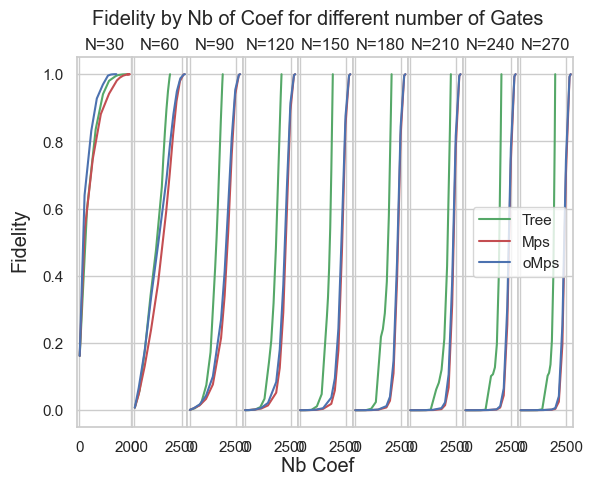

In [53]:
# N,CHI,RES_tree,RES_mps,RES_omps,MEM_tree,MEM_mps,MEM_omps = zip(*results)

N = df_results['N']
CHI = df_results['chi']
RES_tree = df_results['f_tree']
RES_mps = df_results['f_mps']
RES_omps = df_results['f_omps']
MEM_tree = df_results['mem_tree']
MEM_mps = df_results['mem_mps']
MEM_omps = df_results['mem_omps']

chi_range = range(int(np.min(CHI)),int(np.max(CHI))+1,int(CHI[1]-CHI[0]))
N_gate_range = range(int(np.min(N)),int(np.max(N))+1,int(N[len(chi_range)]-N[0]))

# RES = np.array(RES).reshape(len(N),len(CHI))
N = np.array(N).reshape(len(N_gate_range),len(chi_range))
CHI = np.array(CHI).reshape(len(N_gate_range),len(chi_range))
RES_tree = np.array(RES_tree).reshape(len(N_gate_range),len(chi_range))
RES_mps = np.array(RES_mps).reshape(len(N_gate_range),len(chi_range))
RES_omps = np.array(RES_omps).reshape(len(N_gate_range),len(chi_range))
MEM_tree = np.array(MEM_tree).reshape(len(N_gate_range),len(chi_range))
MEM_mps = np.array(MEM_mps).reshape(len(N_gate_range),len(chi_range))
MEM_omps = np.array(MEM_omps).reshape(len(N_gate_range),len(chi_range))

# plt.plot(MEM_tree[i],RES_tree[i],color='g')
# plt.plot(MEM_mps[i],RES_mps[i],color='r')
# plt.show()


fig = plt.figure()
gs = fig.add_gridspec(1, len(N.T[0]), hspace=0, wspace=0)
axes = gs.subplots(sharex='col', sharey='row')
fig.suptitle('Fidelity by Nb of Coef for different number of Gates')
fig.supxlabel('Nb Coef')
fig.supylabel('Fidelity')

# fig, axes = plt.subplots(1,9,sharey=True)

for i in range(len(N.T[0])):
    axes[i].plot(MEM_tree[i],RES_tree[i],color = 'g',label = 'Tree')
    axes[i].plot(MEM_mps[i],RES_mps[i],color = 'r',label = 'Mps')
    axes[i].plot(MEM_omps[i],RES_omps[i],color = 'b',label = 'oMps')
    axes[i].set_title('N='+str(int(N.T[0][i])))

axes[-1].legend()
# for ax in axes.flat:
#     ax.set(xlabel='Nb Coef', ylabel='Fidelity')
for ax in axes.flat:
    ax.label_outer()

plt.tight_layout()

plt.show()

## tidying

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tidy dataframe creation (as before)
df = pd.DataFrame(results)

methods = ['tree', 'mps', 'omps']
tidy_df = pd.DataFrame()

for method in methods:
    method_df = pd.DataFrame({
        'N': df['N'],
        'chi': df['chi'],
        'method': method.upper(),
        'fidelity': df[f'f_{method}'] if f'f_{method}' in df else df[f'fidelity_{method}'],
        'fidelity_std': df[f'f_std_{method}'],
        'memory': df[f'mem_{method}'],
        'memory_std': df[f'mem_std_{method}']
    })
    tidy_df = pd.concat([tidy_df, method_df], ignore_index=True)

## fidelity on mem

C:\Users\titou\AppData\Local\Temp\ipykernel_10560\1863790323.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


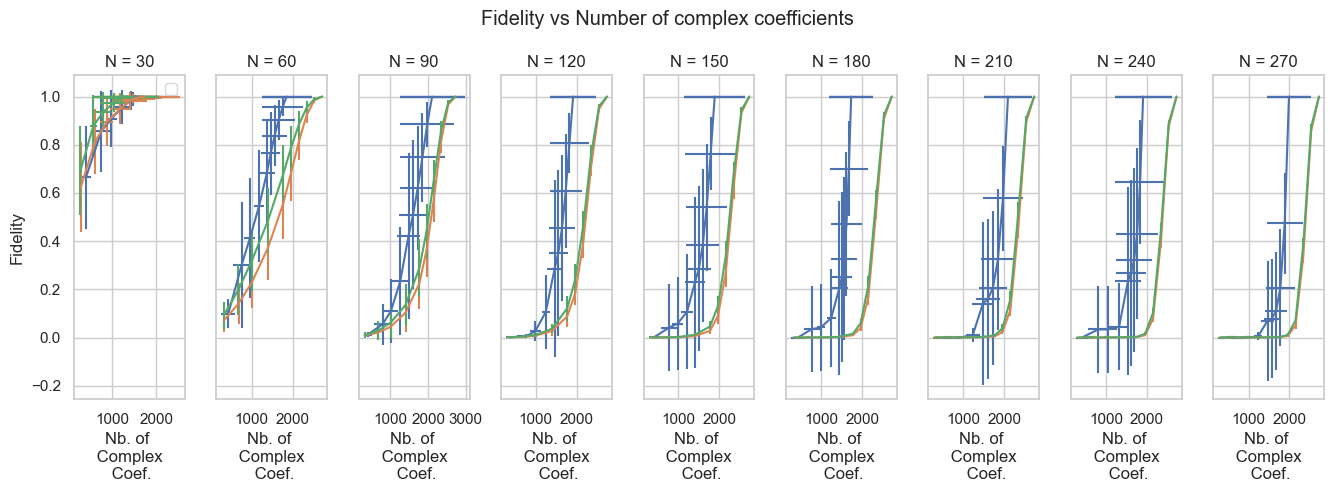

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="notebook")

unique_Ns = sorted(tidy_df['N'].unique())
# ncols = 2
# nrows = (len(unique_Ns) + 1) // ncols
ncols = len(unique_Ns)
nrows = 1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(1.5 * ncols, 5 * nrows), sharex=False, sharey=True)
axes = axes.flatten()

palette = {'TREE': 'C0', 'MPS': 'C1', 'OMPS': 'C2'}

for i, N_val in enumerate(unique_Ns):
    ax = axes[i]
    subset = tidy_df[tidy_df['N'] == N_val]

    for method in ['TREE', 'MPS', 'OMPS']:
        sub = subset[subset['method'] == method]
        
        # Sort by memory to avoid jagged lines
        sub = sub.sort_values(by='memory')
        
        # Plot line
        # ax.plot(sub['memory'], sub['fidelity'], label=method, color=palette[method])
        ax.errorbar(sub['memory'],sub['fidelity'],yerr = sub['fidelity_std'],xerr=sub['memory_std'])
        
        # Plot error band
        # ax.fill_between(
        #     sub['memory'],
        #     sub['fidelity'] - sub['fidelity_std'],
        #     sub['fidelity'] + sub['fidelity_std'],
        #     alpha=0.2,
        #     color=palette[method]
        # )
        # ax.fill_between(
        #     sub['memory'],
        #     sub['memory'] - sub['memory_std'],
        #     sub['memory'] + sub['memory_std'],
        #     alpha=0.2,
        #     color=palette[method]
        # )

    ax.set_title(f'N = {N_val}')
    ax.set_xlabel('Nb. of \n Complex \n Coef.')
    # ax.set_ylabel('Fidelity')
    # ax.legend()
    ax.grid(True)

axes[0].set_ylabel('Fidelity')
axes[0].legend()

# Clean up unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Fidelity vs Number of complex coefficients')

plt.tight_layout()
plt.show()

## mem for min f on N

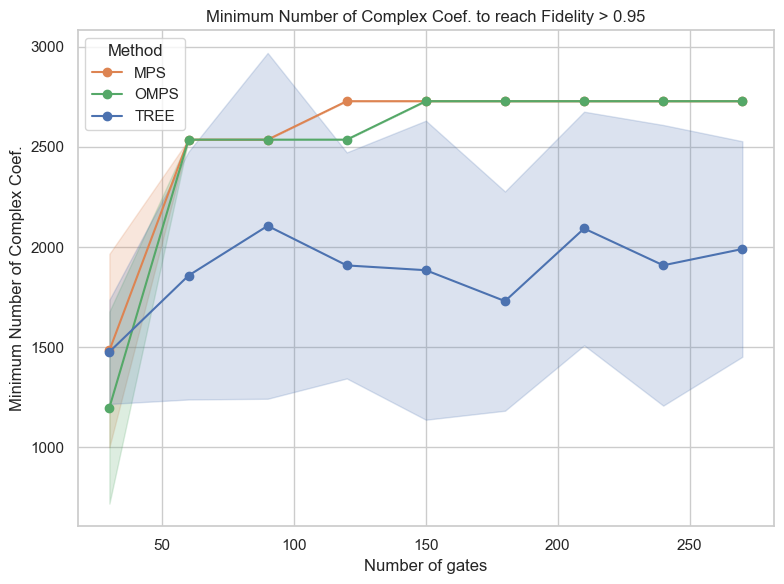

In [26]:
threshold = 0.95

# Conservative fidelity: subtract std to ensure it's safely above the threshold
conservative_df = tidy_df[tidy_df['fidelity'] - tidy_df['fidelity_std'] > threshold]

# For each N and method, get the row with min memory
min_mem_with_uncertainty = (
    conservative_df
    .sort_values('memory')
    .groupby(['N', 'method'], as_index=False)
    .first()  # First row after sorting by memory == minimum memory
)

# Rename for clarity
min_mem_with_uncertainty = min_mem_with_uncertainty.rename(columns={
    'memory': 'min_mem',
    'memory_std': 'min_mem_std'
})


sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))

methods = min_mem_with_uncertainty['method'].unique()
palette = {'TREE': 'C0', 'MPS': 'C1', 'OMPS': 'C2'}

for method in methods:
    sub = min_mem_with_uncertainty[min_mem_with_uncertainty['method'] == method]
    
    # Sort for line plotting
    sub = sub.sort_values(by='N')
    
    # Plot line
    plt.plot(sub['N'], sub['min_mem'], label=method, marker='o', color=palette[method])
    
    # Plot error band
    plt.fill_between(
        sub['N'],
        sub['min_mem'] - sub['min_mem_std'],
        sub['min_mem'] + sub['min_mem_std'],
        alpha=0.2,
        color=palette[method]
    )

plt.title(f"Minimum Number of Complex Coef. to reach Fidelity > {threshold}")
plt.xlabel("Number of gates")
plt.ylabel("Minimum Number of Complex Coef.")
plt.legend(title="Method")
plt.tight_layout()
plt.show()